In this notebook, we train our DualEncoder-FNO model. Copy of v3, but this version includes:
- Data augmentation (no cumulative transformation).
- Dropout 0.05
- ReduceLROnPlateau as lr scheduler
- 200 epochs with early stopping (patience = 10)
- Architecture: n_modes = 16, n_hidden =64
- Sinusoidal embedding

### 1. Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from neuralop import LpLoss, H1Loss
from neuralop import FNO
from rve_analyzer import RVEDataset, DualEncoderFNO, Trainer, EquilibriumLoss, HomogenizedLoss

### 2. Configuration

In [2]:
from types import SimpleNamespace

cfg = SimpleNamespace(**{})

In [3]:
cfg.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {cfg.device}")

Device: cuda


In [4]:
cfg.h5_path = Path("../master_data/rve_run2.h5")
cfg.batch_size = 64
cfg.num_workers = 0
cfg.seed = 42
torch.manual_seed(cfg.seed)
np.random.seed(cfg.seed)

### 3. Datasets & DataLoader

In [5]:
cfg.in_memory = True
cfg.fraction = 1.00

train_dataset = RVEDataset(cfg.h5_path, split='train', in_memory=cfg.in_memory, fraction=cfg.fraction, augment=True)
val_dataset   = RVEDataset(cfg.h5_path, split='val', in_memory=cfg.in_memory, fraction=cfg.fraction, augment=False)

print(f"Train: {len(train_dataset)} | Val: {len(val_dataset)}")

# Get dimensions
sample_xl, sample_xg, sample_y = train_dataset[0]
in_channels = sample_xl.shape[0]      # phase + nstatev + ...
out_channels = sample_y.shape[0]
n_macro = sample_xg.shape[0]

print(f"in_channels={in_channels}, out_channels={out_channels}, n_macro={n_macro}")


Loading 100% of 'train' split into RAM. This may take a moment...
Loading 100% of 'val' split into RAM. This may take a moment...
Train: 60000 | Val: 20000
in_channels=1, out_channels=3, n_macro=3


In [6]:
def save_normalizers(dataset, save_dir="../checkpoints", filename="rve_fno_normalizers.pth"):
    """
    Save normalizer objects
    """

    path = Path(save_dir)
    path.mkdir(exist_ok=True, parents=True)
    
    normalizers = {
        'x_normalizer': getattr(dataset, 'x_normalizer', None),
        'global_normalizer': getattr(dataset, 'global_normalizer', None),
        'y_normalizer': getattr(dataset, 'y_normalizer', None)
    }
    
    save_path = path / filename
    torch.save(normalizers, save_path)
    
    print(f"Normalizers save in: {save_path}")

# save_normalizers(train_dataset, filename = "rve2_fno_normalizers.pth")

In [7]:
def check_normalization_per_channel(dataset, in_channels, n_macro, out_channels, batch_size=32):
    """
    """
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False, num_workers=0)
    
    # Initialize zero tensors to accumulate sum and squared sum per channel
    xl_sum = torch.zeros(in_channels)
    xl_sq_sum = torch.zeros(in_channels)
    xl_count = 0
    
    xg_sum = torch.zeros(n_macro)
    xg_sq_sum = torch.zeros(n_macro)
    xg_count = 0
    
    y_sum = torch.zeros(out_channels)
    y_sq_sum = torch.zeros(out_channels)
    y_count = 0

    print("Computing mean and standard deviation per channel...")

    for xl, xg, y in loader:
        B = xl.size(0)  # Current batch size
        
        # Process x_local: [B, C_in, H, W] -> Flatten spatial dims to [B, C_in, N]
        xl_flat = xl.view(B, in_channels, -1)
        # Sum along the batch dimension (0) and spatial pixels (2), preserving channels (1)
        xl_sum += xl_flat.sum(dim=(0, 2))
        xl_sq_sum += (xl_flat ** 2).sum(dim=(0, 2))
        # Total elements per channel: Batch size * Number of pixels
        xl_count += B * xl_flat.size(2)
        
        # Process x_global: Assuming shape [B, n_macro] (no spatial dimensions)
        xg_sum += xg.sum(dim=0)
        xg_sq_sum += (xg ** 2).sum(dim=0)
        xg_count += B
        
        # Process y_local: [B, C_out, H, W] -> Flatten to [B, C_out, N]
        y_flat = y.view(B, out_channels, -1)
        y_sum += y_flat.sum(dim=(0, 2))
        y_sq_sum += (y_flat ** 2).sum(dim=(0, 2))
        y_count += B * y_flat.size(2)

    # Helper function to compute the final mean and std per channel
    def get_channel_stats(c_sum, c_sq_sum, count):
        mean = c_sum / count
        # Variance = E[X^2] - (E[X])^2
        variance = (c_sq_sum / count) - (mean ** 2)
        # Clamp to 0 to avoid negative variances due to floating-point precision errors
        variance = torch.clamp(variance, min=0.0)
        std = torch.sqrt(variance)
        return mean, std

    # Compute final statistics
    xl_mean, xl_std = get_channel_stats(xl_sum, xl_sq_sum, xl_count)
    xg_mean, xg_std = get_channel_stats(xg_sum, xg_sq_sum, xg_count)
    y_mean, y_std = get_channel_stats(y_sum, y_sq_sum, y_count)

    # Print the final report
    print("\n" + "="*50)
    print("NORMALIZATION REPORT")
    print("="*50)

    def print_stats(name, mean_tensor, std_tensor, tol=0.05):
        print(f"\n--- {name} ---")
        for i, (m, s) in enumerate(zip(mean_tensor, std_tensor)):
            # Visual warning if a channel deviates from Mean=0 and Std=1
            status = "✅" if (abs(m.item()) < tol and abs(s.item() - 1.0) < tol) else "⚠️"
            print(f"Channel {i}: Mean = {m.item():7.4f} | Std = {s.item():7.4f}  {status}")

    print_stats("x_local (in_channels)", xl_mean, xl_std)
    print_stats("x_global (n_macro)", xg_mean, xg_std)
    print_stats("y_local (out_channels)", y_mean, y_std)
    print("\n" + "="*50)

# Execute the check on the training dataset
check_normalization_per_channel(train_dataset, in_channels, n_macro, out_channels, batch_size=cfg.batch_size )

Computing mean and standard deviation per channel...

NORMALIZATION REPORT

--- x_local (in_channels) ---
Channel 0: Mean = -0.0000 | Std =  1.0000  ✅

--- x_global (n_macro) ---
Channel 0: Mean =  0.0276 | Std =  1.0092  ✅
Channel 1: Mean = -0.0273 | Std =  0.9917  ✅
Channel 2: Mean =  0.0066 | Std =  1.0000  ✅

--- y_local (out_channels) ---
Channel 0: Mean =  0.0060 | Std =  0.9967  ✅
Channel 1: Mean = -0.0060 | Std =  1.0034  ✅
Channel 2: Mean =  0.0007 | Std =  1.0000  ✅



In [8]:
persistent_workers = True if cfg.num_workers > 0 else False
prefetch_factor = 4 if cfg.num_workers > 0 else None

train_loader = DataLoader(train_dataset, batch_size=cfg.batch_size, shuffle=True,
                          num_workers=cfg.num_workers, pin_memory=True, 
                          persistent_workers=persistent_workers, prefetch_factor=prefetch_factor)

val_loader   = DataLoader(val_dataset,   batch_size=cfg.batch_size, shuffle=False,
                          num_workers=cfg.num_workers, pin_memory=True, 
                          persistent_workers=persistent_workers, prefetch_factor=prefetch_factor)

In [9]:
# Test one batch
for x_local, x_global, y_local in train_loader:
        print(f"x_local shape : {x_local.shape}")   # (B, 1, 96, 96)
        print(f"x_global shape: {x_global.shape}")  # (B, 3)
        print(f"y_local shape : {y_local.shape}")   # (B, 3, 96, 96)
        print("")
        # print(x_local[0,0,:,:])
        # print(x_global[1,:])
        # print(y_local[0,1,:,:])
        break

x_local shape : torch.Size([64, 1, 96, 96])
x_global shape: torch.Size([64, 3])
y_local shape : torch.Size([64, 3, 96, 96])



In [10]:
def show_batch_channels(dataloader: DataLoader,
                     channel: int = 0,
                     title: str = "RVEs batch", 
                     nrow: int = 8, 
                     space: float = 0.15,
                     ):

    x_local, _, _ = next(iter(dataloader))
    x_local = x_local[:, channel:(channel+1)].cpu()     # only for selected channel
    
    n_images = x_local.shape[0]
    
    # Grid
    nrow = min(nrow, int(np.ceil(np.sqrt(n_images))))
    ncol = int(np.ceil(n_images / nrow))
    
    factor = 2.5
    fig = plt.figure(figsize=(nrow*factor, ncol*factor), facecolor='white')
    fig.suptitle(title, fontsize=15, y=0.95, fontweight='bold')
    
    # Subplots
    gs = fig.add_gridspec(nrow, ncol, wspace=space, hspace=space)
    
    for idx in range(n_images):
        ax = fig.add_subplot(gs[idx // ncol, idx % ncol])

        im = ax.imshow(x_local[idx, 0].numpy(), cmap='viridis', vmin=0, vmax=1)
        
        ax.set_facecolor('white')
        ax.axis('off')
    
    fig.subplots_adjust(top=.91, bottom=0.05)
    cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
    fig.colorbar(im, cax=cbar_ax,)
    
    plt.show()

In [11]:
# show_batch_channels(train_loader,
#                    channel = 0,        # Material phase
#                    title='Train batch example - RVE microestructure'
#                 )

### 4. Model configuration

In [12]:
# Build model base on HPO analyis.
# We based on trial 27.
cfg.best_params = {
    "n_modes": 16,
    "hidden_channels": 64,
    "n_layers": 4,
    "channel_mlp_dropout": 0.05,
    "film_mlp_layers": 2,
    "film_mlp_neurons": 128,
    "film_mlp_dropout": 0.00,
    "use_sinusoidal_emb": True,
    "sin_emb_nfreq": 6,
}

model = DualEncoderFNO(
    in_channels         = in_channels,
    out_channels        = out_channels,
    n_macro             = n_macro,
    **cfg.best_params,
    use_positional_grid = True,
    film_per_layer      = True,
    ).to(cfg.device)

model.save_config("../checkpoints/rve2_fno_v6_config.pth")

Saved configuration at ../checkpoints/rve2_fno_v6_config.pth


In [13]:
n_params = model.count_parameters()
print(f"\nOur model has {n_params} parameters.")


Our model has 4839363 parameters.


### 5. Training

In [14]:
cfg.epochs = 200

cfg.lr = 1e-3
cfg.weight_decay = 1e-4
cfg.patience = 10
cfg.max_grad_norm = 1.0
cfg.lr_min = 1e-6

l2loss = LpLoss(d=2, p=2, reduction='mean')     # L2 loss for function values
h1loss = H1Loss(d=2, reduction='mean')
hgloss = HomogenizedLoss()

val_metrics = {
    'l2': l2loss,
    'h1': h1loss,
    'hg': hgloss,
}

In [15]:
trainer = Trainer(
    model=model,
    loss_fun=h1loss,
    val_metrics=val_metrics,
    wandb_log=False,
    device=cfg.device,
    save_dir="../checkpoints",
    min_delta=1e-7,
    max_grad_norm=cfg.max_grad_norm,
    verbose=True
)

In [16]:
optimizer = torch.optim.AdamW(
  model.parameters(),
  lr = cfg.lr,
  weight_decay = cfg.weight_decay,
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,          # Reduce LR to the half when it plateaus
    patience=5,          # Wait 5 epochs without improvement before reducing
    threshold=1e-4,      # Minimum improvement to not consider stagnation
    min_lr=cfg.lr_min,   # Do not decrease LR below 1e-6
)

history = trainer.fit(
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=cfg.epochs,
    optimizer=optimizer,
    scheduler=scheduler,
    patience=cfg.patience,
    model_name="rve2_fno_v6_params.pth",
    verbose=True
)

DualEncoderFNO Training: 200 epochs



   Best model saved (Epoch 1)
Epoch   1/200 | Train Loss: 0.592837 | Val Loss: 0.418146 | Val L2: 0.638261 | H1: 0.418146 | HG: 0.739301 | LR: 1.00e-03


   Best model saved (Epoch 2)
Epoch   2/200 | Train Loss: 0.389456 | Val Loss: 0.324676 | Val L2: 0.586745 | H1: 0.324676 | HG: 0.728819 | LR: 1.00e-03


   Best model saved (Epoch 3)
Epoch   3/200 | Train Loss: 0.325950 | Val Loss: 0.283247 | Val L2: 0.556747 | H1: 0.283247 | HG: 0.711555 | LR: 1.00e-03


   Best model saved (Epoch 4)
Epoch   4/200 | Train Loss: 0.288648 | Val Loss: 0.259032 | Val L2: 0.532185 | H1: 0.259032 | HG: 0.683585 | LR: 1.00e-03


...

Epoch 158/200 | Train Loss: 0.105068 | Val Loss: 0.125489 | Val L2: 0.160346 | H1: 0.125489 | HG: 0.146709 | LR: 7.81e-06


Epoch 159/200 | Train Loss: 0.104993 | Val Loss: 0.125342 | Val L2: 0.160493 | H1: 0.125342 | HG: 0.147188 | LR: 7.81e-06


Epoch 160/200 | Train Loss: 0.104985 | Val Loss: 0.125459 | Val L2: 0.160394 | H1: 0.125459 | HG: 0.146791 | LR: 7.81e-06


Epoch 161/200 | Train Loss: 0.104974 | Val Loss: 0.125439 | Val L2: 0.160641 | H1: 0.125439 | HG: 0.147531 | LR: 7.81e-06


Epoch 162/200 | Train Loss: 0.104977 | Val Loss: 0.125400 | Val L2: 0.160333 | H1: 0.125400 | HG: 0.146740 | LR: 7.81e-06
Early stopping triggered at epoch 162

 Training finished. Best epoch: 152 (Loss = 0.125326)
Total training time: 19:42:29.25


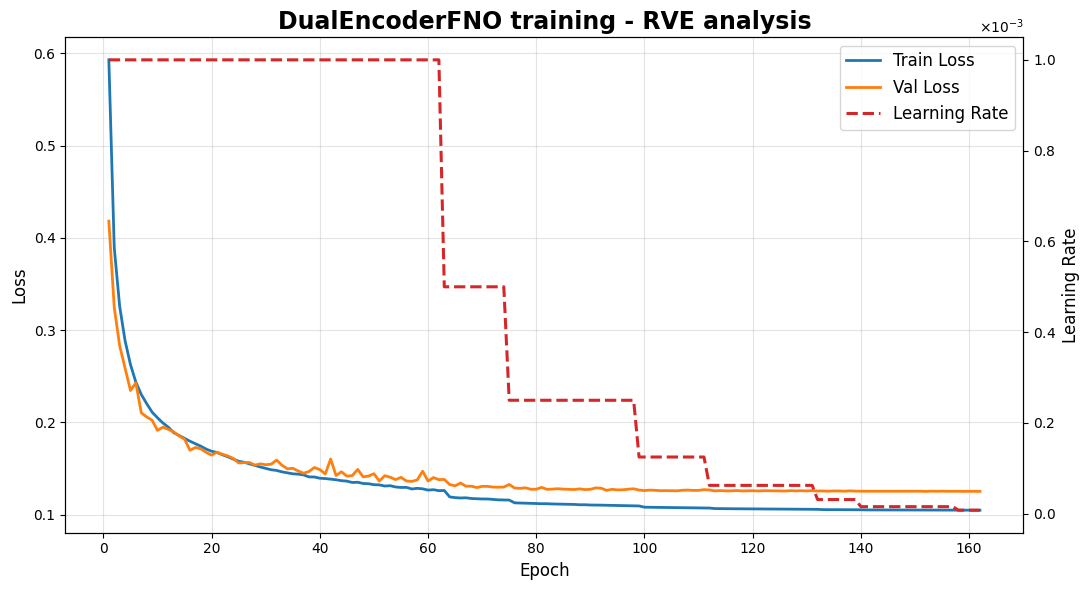

In [17]:
trainer.plot_history(title="DualEncoderFNO training - RVE analysis")

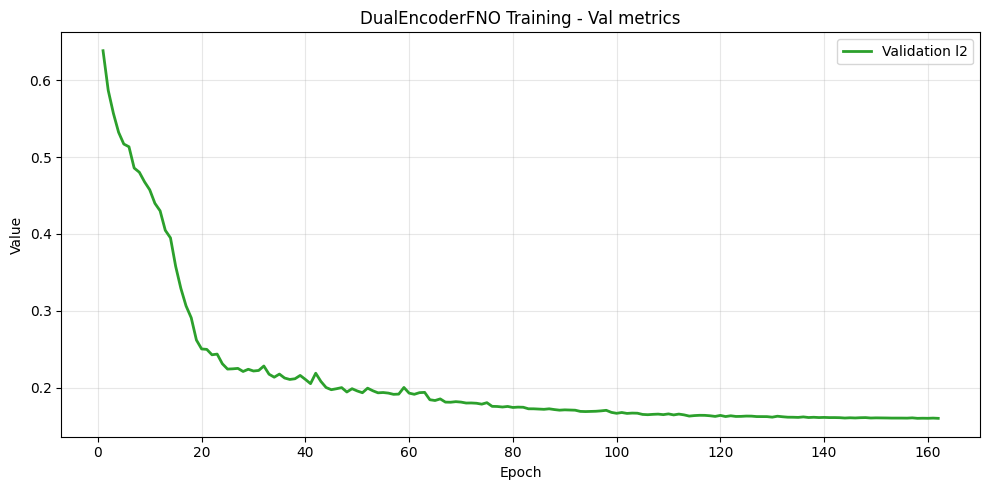

In [18]:
trainer.plot_metric(metric_name='l2')

tiempo 898